# Chapter 2: Neural Language Modeling

In the first chapter we saw how to build Markov models to generate text. We also saw that one of their main limitations is the problem of modeling long range sequences. In the second chapter we learn how we can use Deep Learning to build models that can learn through data. In this chapter we will see how we can use deep learning to improve the Markov model.

<img src="./gate.png" alt="Neuron" width="800" height="400">

The problem with Markov chains is that the next token probability is only based on the previous token or tokens. To improve our modeling capacity we need to be able to produce a different probability distribution based on the current state of the token. For, example the probability of the tokens inside a if statement is different from the probabilities inside a loop or a function definition.

## Neural Markov

Let's start by recreating the Markov model using neural networks. Let's use the same text from the first chapter.

In [2]:
import requests
from bs4 import BeautifulSoup
import re

url = 'https://en.wikipedia.org/wiki/Computer'
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
doc = BeautifulSoup(response.text, 'html.parser')
text = '\n'.join([x.text for x in doc.find('div', {'id': 'bodyContent'})])
cleaned_text = re.sub(r'\n+', '\n', text)

Then, the same tokenization and vocabulary building functions.

In [3]:
def tokenize(text, n_grams, sliding=True):
    if not sliding:
        return [''.join(x) for x in itertools.batched(text, n_grams)]

    tokens = []
    for i in range(len(text) - n_grams + 1):
        tokens.append(text[i:i+n_grams])
    return tokens

def build_vocab(tokens):
    vocab = list(set(tokens))
    wi = {c: i for i, c in enumerate(vocab)}
    iw = {i: c for i, c in enumerate(vocab)}
    return wi, iw

Let's build our training data by tokenizing the text and building the vocabulary. We will use n-grams of size 1 for now:

In [4]:
n_grams = 1
tokens = tokenize(cleaned_text, n_grams)
wi, iw = build_vocab(tokens)
print('Vocabulary size:', len(wi))
print('Number of tokens:', len(tokens))

Vocabulary size: 108
Number of tokens: 103341


Now we can build our training data. Our objective will be to predict the next token given the previous token. This is the same architecture we used to train a classifier in the second chapter. But instead of 3 flower classes, each token in our vocabulary will be a class:

![](https://mermaid.ink/img/pako:eNqtUstOwzAQ_BVrz3kR203sAyot4saNE8rFNM4DJXHkOGohzb9jJ1Sg3oqwpfXu7M7sHDzBQeUSOBSNOh4qoQ3avWQdsudpOzXiTTYcZRAFFJ1RFKRLxEu8y2BGvn9_LqQwo5bDGT1brWZlL6lro4fthOq2dDKVMf3Aw7BuRSmHoJcn2QzBQbVhXymjhjBJI4xTGq4df0H9bzB472WZgYd6NTgx4_IjR5vIQ9X6HFQ3GC3qzrgB1WWA5ms7u1vsYBaTiF3ZWcF_srO_wQ6mLKFxfOXngv7Z0OU6Y-BBqescuNGj9KCVuhWuhMn1rWglW5mBo-eyEGNjt2TdbGm96F6Vai9MrcayAl6IZrDV2OfCyMdalFr8jMgul3qvxs4Ap4sC8AlOtkgDvEkSTCiNYkoIJR58WJgFBCeEpoxgzCLGZg8-l532ZyaE_T7zF9x83dA?type=png)


![](https://mermaid.ink/img/pako:eNpdjk1PwzAMhv9K5HNXlSWhbQ4IMcSNGyeUi7e47aQ0mbJEfHT97zSdQGj2xe9jv7YnOHhDoKCz_uMwYIjs6U07tsTL42RxT1YxDTsNM9tsHi4dYUyBzhf2uvjsdXItc5vhLdjfAq_dNTOGAvpwNKBiSFTASGHELGHKfQ1xoJE05A8MdZhs1KDdvNhO6N69H3-dwad-ANWhPS8qnQxGej5iH3D8o4GcobDzyUVQW7nuADXBJyjZlPy-rrmQstpKIaQo4GvBbSl4LWTTCs7bqm3nAr7Xq1XZ1LL6F3fzD9_jYhw?type=png)

With this architecture we can generate text in a similar way as our first Markov model, we predict the next token and then we feed it back to the input to continue the generation.

Let's build this example starting with the training dataset. We can write a function that given a sequence of tokens $x$ we will predict the next token $y$.


In [4]:
def build_dataset(tokens, sequence_length=1, slide=1):

    x = []
    y = []

    for i in range(0, len(cleaned_text) - l, s):
        x.append([wi[q] for q in cleaned_text[i:i+l]])
        y.append(wi[cleaned_text[i+l]])

dataset = TensorDataset(torch.LongTensor(x), torch.LongTensor(y))
print(len(dataset))

105533


In [7]:
import torch
from torch.utils.data import TensorDataset

def build_dataset(tokens, sequence_length=1, slide=1):

    x = []
    y = []

    for i in range(0, len(tokens) - sequence_length, slide):
        x.append([wi[q] for q in tokens[i:i+sequence_length]])
        y.append(wi[tokens[i+sequence_length]])

    return TensorDataset(torch.LongTensor(x), torch.LongTensor(y))

dataset = build_dataset(tokens, sequence_length=1, slide=1)
print(len(dataset))

103340


Now we can build our model. We will use a linear layer with input size 1 (the current token) and output size equal to the vocabulary size (the next possible tokens). Then to compute the probability distribution we will apply a log softmax to the output of the linear layer. This is the same architecture we used to train a classifier in the second chapter, but now instead of 3 classes we have as many classes as tokens in our vocabulary.

In [11]:
import torch.nn as nn

class NeuralMarkov(nn.Module):
    def __init__(self, vocab_size):
        super(NeuralMarkov, self).__init__()
        self.lm = nn.Sequential(
            nn.Linear(1, vocab_size),
            nn.LogSoftmax(dim=-1)
        )

    def forward(self, x):
        return self.lm(x.float())

Our training function is the same from the last chapter used to train the Iris classifier.

In [17]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

def train(model, dataset, epochs=10, batch_size=16, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.NLLLoss()
    lh = []
    progress = tqdm(total=len(dataset) * epochs)
    for epoch in range(epochs):
        el = []
        for (x, y) in DataLoader(dataset, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            o = model(x)
            loss = crit(o, y)
            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))

    progress.close()
    plt.plot(lh)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

Now we can train our model using the train function:

  0%|          | 0/1033400 [00:00<?, ?it/s]

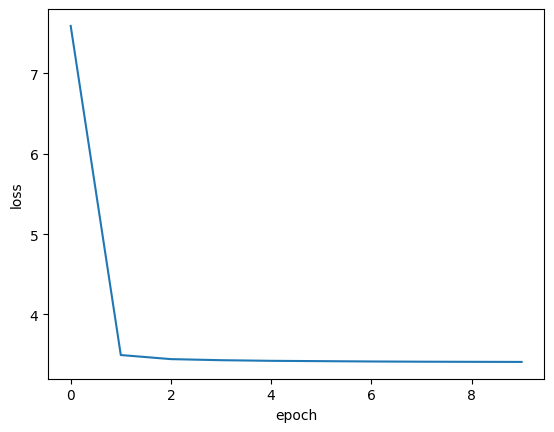

In [18]:
vocab_size = len(wi)
model = NeuralMarkov(vocab_size)
train(model, dataset, epochs=10, batch_size=16, lr=0.001)

We can see that our loss got stuck around 3.5. This is because our model is not able to model correctly our text since it only sees the previous token. Also, the loss is correlated with the perplexity of the model. A lower loss corresponds to lower perplexity and from the experiments in the first chapter we know that increasing the n-grams size decreases the perplexity.

Generating text with this model follows the same procedure as our Markov model. We start with a seed token and then we get the probabilities of the next token using our model. We sample from the probability distribution to get the next token and then we append it to the input text.

In [25]:
def gen(model, text, max_tokens=100):
    # convert our text tokens to tensors
    x = torch.LongTensor([wi[text]]).unsqueeze(0)

    for _ in range(max_tokens):
        with torch.no_grad():
            # sample the probabilities of the next tokens
            log_probs = model(x)

        # our probabilities are in log space so we take the exp
        probs = log_probs.exp()

        # the next token is the one with the highest probability
        next_token = probs.argmax().item()

        # append the generated token to the text
        text += iw[next_token]

        # the next token is now the current token
        x = torch.LongTensor([next_token]).unsqueeze(0)

    return text

Let's see how our model generates text:

In [26]:
text = 'C'
generated_text = gen(model, text, max_tokens=100)
print(generated_text)

C te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te 


Is possible that our model enters in a loop and generates the same token over and over again. To avoid this we can apply the same solution we used in the first chapter and sample from the probability distribution instead of taking the token with the highest probability.

In [27]:
def gen(model, text, max_tokens=100):
    x = torch.LongTensor([wi[text]]).unsqueeze(0)

    for _ in range(max_tokens):
        with torch.no_grad():
            log_probs = model(x)

        probs = log_probs.exp()

        # we sample from the distribution instead of getting the most probable token every time
        next_token = torch.multinomial(probs, 1).item()

        text += iw[next_token]
        x = torch.LongTensor([next_token]).unsqueeze(0)

    return text


text = 'C'
generated_text = gen(model, text, max_tokens=100)
print(generated_text)

Coat tralyelsao mi nu ,ses. rrlsoVs afncmi o cnteinD iat ter,y 6in1le 0rcFP^en nauu atrnuaurttiaoi  r


By sampling from the distribution we can get more diverse text that helps escaping generation loops.

We can see in the generate text example that the model is being able to model the space between words but the worlds themselves are not being generated correctly. We already know that increasing the n-grams can improve the generation quality but won't solve the main problem of long range dependencies. To solve this let's improve our neural architecture.

Remember from last chapter that neural networks don't like unormalized data. And we are using the token indices as input to our model, which makes difficult for our model as tokens with higher indices will have higher rotations from the linear layers. But how can we normalize our input data? Since our data is made of tokens that are a type of categorical data we can use the one-hot encoding to normalize our data.

With one-hot encoding we can represent our categories with a numerical vector. It works by creating a vector of zeros with the same length as the number of categories and then we set the index of the category to 1. For example suppose we have a vocabulary of 3 letters A, B, and C. We start a vector of zeros for each category like this table:

| | A | B | C |
|---|---|---|---|
| A | 0 | 0 | 0 |
| B | 0 | 0 | 0 |
| C | 0 | 0 | 0 |

Then we set to 1 each column index for each category:

| | A | B | C |
|---|---|---|---|
| A | 1 | 0 | 0 |
| B | 0 | 1 | 0 |
| C | 0 | 0 | 1 |

This helps our model learn better as the norm of our data is always 1. Let's implement this in our model:

In [32]:
class NeuralMarkov(nn.Module):
    def __init__(self, vocab_size):
        super(NeuralMarkov, self).__init__()
        self.lm = nn.Sequential(
            # the input size is now the size of the vocabulary
            nn.Linear(vocab_size, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.vocab_size = vocab_size

    def forward(self, x):
        # converting our token indices to one hot encoding
        one_hot = nn.functional.one_hot(x, self.vocab_size).float()
        return self.lm(one_hot.squeeze(1))

  0%|          | 0/1033400 [00:00<?, ?it/s]

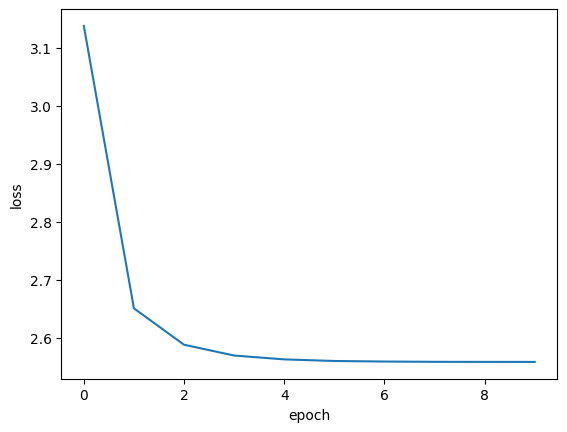

In [33]:
vocab_size = len(wi)
model = NeuralMarkov(vocab_size)
train(model, dataset, epochs=10, batch_size=16, lr=0.001)

Our model is now able to have a lower loss due to the normalization of the input data. Let's see how our model generates text now:

In [34]:
s = 'C'
txt = gen(model, s, max_tokens=100)
print(txt)

Cors
ETon fg n 131
Mers, 2, S moff ass, tal idubambrte ctry becerle dalisedwar d AMorstindiricanstare


While the loss is lower, we can't see a significant improvement in the generated text. This is because our model is still only looking only at the previous token to predict the next one. To improve our model we need to increase the context size, that is, the number of previous tokens that our model looks at to predict the next token. For this, we can use the same approach we used to improve our Markov model in the first chapter by using a fixed sequence of tokens to predict the next token.

Implementing this in our model is straightforward, as we can just concatenate the one-hot encodings of the previous tokens in the sequence and feed this larger vector to our linear layer. For example, suppose we have a sequence of 4 tokens with a vocabulary size of 3. So each token will be encoded as a one-hot vector of size 3 and concatenating all tokens give us a final vector of 12 elements.

Let's first build our dataset with a sequence of 4 tokens as input and the next token as output:

In [35]:
dataset = build_dataset(tokens, sequence_length=4, slide=1)
print(len(dataset))
print(dataset[0][0].shape)

103337
torch.Size([4])


Now we have our dataset with sequences of 4 tokens as input and the next token as output.

To implement this larger context in our model we multiply the input size of our linear layer by the context size, and concatenate the one-hot encodings.

In [67]:
class NeuralMarkov(nn.Module):
    def __init__(self, vocab_size, context_size=4):
        super(NeuralMarkov, self).__init__()
        self.seq = nn.Sequential(
            # the input size is now the context window size multiplyed by the vocabulary size
            nn.Linear(vocab_size * context_size, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.vocab_size = vocab_size

    def forward(self, x):
        one_hot = nn.functional.one_hot(x, num_classes=self.vocab_size).float()
        # concatenating the one-hot vectors
        flatten = torch.flatten(one_hot, start_dim=1).unsqueeze(1)
        return self.seq(flatten)[:, -1]

  0%|          | 0/1033370 [00:00<?, ?it/s]

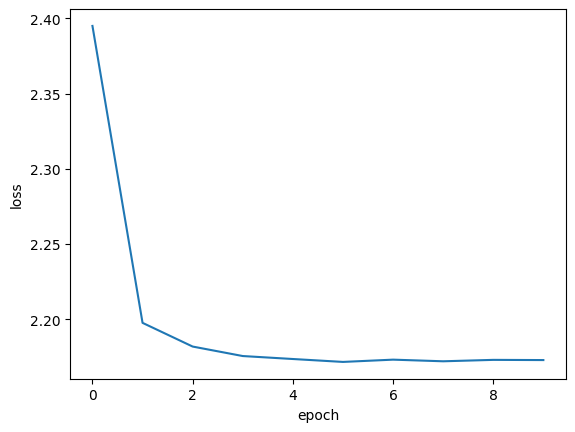

In [75]:
vocab_size = len(wi)
# setting also the context size
model = NeuralMarkov(vocab_size, context_size=4)
train(model, dataset, epochs=10, batch_size=16, lr=0.01)

The greater context gives us lower loss. Let's test our model.

In [77]:
def gen(model, text, max_tokens=100):
    x = torch.LongTensor([wi[q] for q in text]).unsqueeze(0)
    for _ in range(max_tokens):
        with torch.no_grad():
            log_probs = model(x)

        probs = log_probs.exp()

        next_token = torch.multinomial(probs, 1).item()
        text += iw[next_token]
        x = torch.cat([x[:, 1:], torch.LongTensor([[next_token]])], dim=1)

    return text

s = 'Comp'
txt = gen(model, s, max_tokens=200)
print(txt)

Computed's of ts towste boracil-uritho dumm arforathe Inathe st mo re ts tre forit tomse bythese romigga mecturuta. (2. p. 210-8.
Retre) for 4 (1201–512. Res ex mothenis or mashin woul Elscarteme trecumen


With a larger context the model is not able to model some dates and numbers correctly. Also, some small words like "for", "of", "the", "or", etc.

At this point, our model caries the same problem of our Markov model but with an additional problem. By increasing the vocabulary size, we also increase the input size of our linear layer by the same factor. For, example with n-gram = 2 we have about 2000 tokens. An one-hot encoding for a context size of 4 will give us an input vector of size 8000 composed of 7998 zeros and 2 ones. Vectors like this that have a lot of zeros are called sparse vectors and are inefficient since we need to apply computation on them anyway. To solve this problem we can use the knowledge gained from the autoencoders from the last chapter.

## Word Embeddings

We saw in the last chapter that autoencoders can be used to learn a compressed representation of our data.



In [18]:
def tokenize_word(txt):
    tokens = []
    last_word = None
    for c in txt:
        if c.isalnum():
            if last_word is not None:
                last_word += c
            else:
                last_word = c
        else:
            if last_word is not None:
                tokens.append(last_word)
                last_word = None
            if not c.isspace():
                tokens.append(c)
    if last_word is not None:
        tokens.append(last_word)
    return tokens


word_tokens = tokenize_word(cleaned_text)
word_vocab = set(word_tokens)
wv = list(word_vocab)
word_index = {w: i for i, w in enumerate(wv)}
index_word = {i: w for i, w in enumerate(wv)}

In [19]:
i_tokens = [word_index[w] for w in word_tokens]


for each word one embedding

In [20]:
words = torch.LongTensor([1, 4, 2])

embeddings = torch.Tensor([[0, 0, 0],
                           [1, 1, 1],
                           [2, 2, 2],
                           [3, 3, 3],
                           [4, 4, 4]])


word_embeddings = embeddings[words]
print(word_embeddings)

tensor([[1., 1., 1.],
        [4., 4., 4.],
        [2., 2., 2.]])


In [21]:
embeddings = nn.Embedding(5, 3)
embeddings.weight.data = torch.Tensor([[0, 0, 0],
                                      [1, 1, 1],
                                      [2, 2, 2],
                                      [3, 3, 3],
                                      [4, 4, 4]])

words = torch.LongTensor([1, 4, 2])
word_embeddings = embeddings(words)

print(word_embeddings)

tensor([[1., 1., 1.],
        [4., 4., 4.],
        [2., 2., 2.]], grad_fn=<EmbeddingBackward0>)


In [22]:
class Word2Vec(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64):
        super(Word2Vec, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, x):
        return self.embeddings(x)

In [23]:
def build_dataset(tokens, window=5):

    x = []
    y = []
    ws = window // 2
    for i in range(ws, len(tokens) - ws):
        for j in range(i - ws, i + ws + 1):
            if j != i:
                y.append(tokens[j])
                x.append(tokens[i])

    return TensorDataset(torch.LongTensor(x), torch.LongTensor(y))

dataset = build_dataset(i_tokens, window=5)
print(len(dataset))

85608


  0%|          | 0/856080 [00:00<?, ?it/s]

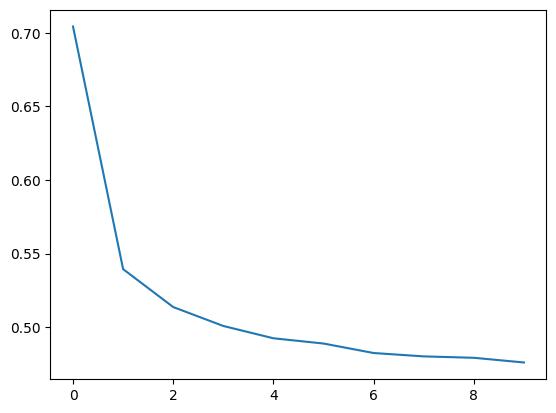

In [24]:
def train_emb(model, dataset, epochs=5, batch_size=16, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CosineEmbeddingLoss()

    progress = tqdm(total=len(dataset) * epochs)
    lh = []
    for _ in range(epochs):
        el = []
        for x, y in DataLoader(dataset, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            xe = model(x)
            pe = model(y)
            ne = model(torch.randint(0, model.embeddings.num_embeddings, y.shape))
            pos_loss = crit(xe, pe, torch.ones(x.shape[0]))
            neg_loss = crit(xe, ne, -torch.ones(x.shape[0]))
            loss = pos_loss + neg_loss
            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])
        lh.append(sum(el) / len(el))

    progress.close()
    plt.plot(lh)
    plt.show()


model = Word2Vec(len(word_vocab), embedding_dim=64)
train_emb(model, dataset, epochs=10, batch_size=16, lr=0.01)

In [25]:


wl = list(range(0, len(word_vocab)))
with torch.no_grad():
    we = model(torch.LongTensor(wl))

print(we.shape)


torch.Size([4342, 64])


In [26]:
word = 'computer'

w1e = we[word_index[word]].unsqueeze(0)
sim = w1e @ we.T
sim /= w1e.norm(dim=-1) * we.norm(dim=-1)

similarities = sim.squeeze().tolist()
similar_words = sorted(zip(similarities, wl), reverse=True)[:10]
for sim, idx in similar_words:
    print(f"{index_word[idx]}: {sim:.4f}")

computer: 1.0000
program: 0.9925
the: 0.9918
modern: 0.9915
electronic: 0.9906
hardware: 0.9903
digital: 0.9894
first: 0.9893
design: 0.9893
control: 0.9887


In [27]:
l = 4
s = 1

x = []
y = []
for i in range(0, len(cleaned_text) - l, s):
    x.append([wi[c] for c in cleaned_text[i:i + l]])
    y.append(wi[cleaned_text[i + l]])

dataset = TensorDataset(torch.LongTensor(x), torch.LongTensor(y))
print(len(dataset))

105530


  0%|          | 0/1055300 [00:00<?, ?it/s]

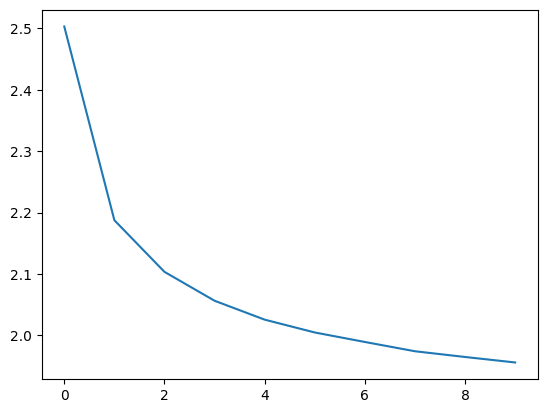

In [28]:
class NeuralMarkov(nn.Module):
    def __init__(self, vocab_size, n_dim=64, context_size=4):
        super(NeuralMarkov, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)
        self.seq = nn.Sequential(
            nn.Linear(n_dim * context_size, n_dim),
            nn.ReLU(),
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )
        self.vocab_size = vocab_size

    def forward(self, h):
        emb = self.emb(h)
        flatten = torch.flatten(emb, start_dim=1).unsqueeze(1)
        return self.seq(flatten)

nm = NeuralMarkov(len(vocab), n_dim=32, context_size=4)
train(nm, dataset, epochs=10, batch_size=16, lr=0.001)

In [29]:

s = 'Comp'
txt = gen(nm, s, max_tokens=100)
print(txt)

Computir, Put adics Canbutions, integratton, it phot kiffarizg.
^ Mrow naky mari CPUxtectragually; progr


In [30]:
l = 4
s = 1

x = []
y = []
for i in range(0, len(cleaned_text) - l, s):
    x.append([wi[c] for c in cleaned_text[i:i + l]])
    y.append(wi[cleaned_text[i + l]])

dataset = TensorDataset(torch.LongTensor(x), torch.LongTensor(y))
print(len(dataset))

105530


In [31]:
class RNN(nn.Module):
    def __init__(self, vocab_size, n_dim=64):
        super(RNN, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)

        self.h_seq = nn.Sequential(
            nn.Linear(n_dim, n_dim),
            nn.Tanh(),
            nn.Dropout(0.2),
        )

        self.o_seq = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )

        self.n_dim = n_dim

    def forward(self, x, h):
        emb = self.emb(x)

        o = []
        for i in range(emb.shape[1]):
            ei = emb[:, i]
            c = ei + h
            h = self.h_seq(c)
            o.append(self.o_seq(c).unsqueeze(1))

        return torch.cat(o, dim=1), h

    def init_hidden(self, batch_size):
        return torch.zeros((batch_size, self.n_dim))

backpropagation through time

  0%|          | 0/1055300 [00:00<?, ?it/s]

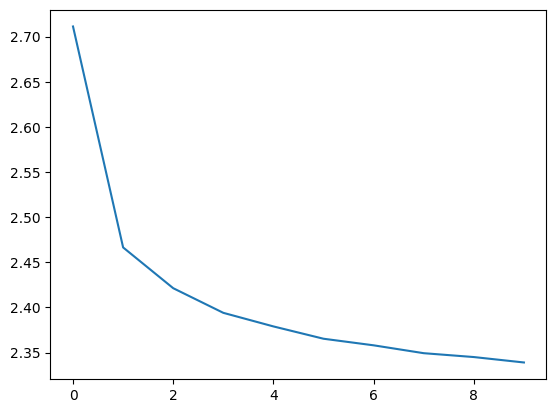

In [32]:
def rnn_train(model, dataset, epochs=10, batch_size=16, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.NLLLoss()

    progress = tqdm(total=len(dataset) * epochs)
    lh = []
    for _ in range(epochs):
        el = []
        for (x, y) in DataLoader(dataset, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            h = model.init_hidden(x.shape[0])
            o, _ = model(x, h)
            loss = crit(o[:, -1], y)

            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))

    progress.close()
    plt.plot(lh)
    plt.show()


rnn = RNN(len(vocab), n_dim=32)
rnn_train(rnn, dataset, epochs=10, batch_size=16, lr=0.001)

In [33]:
def gen_rnn(model, s, max_tokens=100):
    model.eval()
    h = model.init_hidden(1)

    si = [wi[c] for c in s]
    o, h = model(torch.LongTensor(si).unsqueeze(0), h)
    lt = torch.multinomial(o[:, -1].exp(), 1)
    s += iw[lt.item()]
    for _ in range(max_tokens):
        o, h = model(lt, h)
        lt = torch.multinomial(o[:, -1].exp(), 1)
        s += iw[lt.item()]

    return s

s = 'Comp'

txt = gen_rnn(rnn, s, max_tokens=100)
print(txt)

Compumalicouck, Ar P.
^ 1ermistore PU Th war tiep
The Syputer Inse disingite tondealisatticalegish Fromui


In [34]:
class LSTM(nn.Module):
    def __init__(self, vocab_size, n_dim=64):
        super(LSTM, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)

        self.mem = nn.Sequential(
            nn.Linear(n_dim, n_dim),
            nn.Tanh(),
            nn.Dropout(0.2),
        )

        self.reset = nn.Sequential(
            nn.Linear(n_dim, n_dim),
            nn.Sigmoid(),
            nn.Dropout(0.2),
        )

        self.set = nn.Sequential(
            nn.Linear(n_dim, n_dim),
            nn.Sigmoid(),
            nn.Dropout(0.2),
        )

        self.no = nn.Sequential(
            nn.Linear(n_dim, n_dim),
            nn.Sigmoid(),
            nn.Dropout(0.2),
        )

        self.lm = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )

        self.n_dim = n_dim

    def forward(self, x, h, m):
        emb = self.emb(x)
        o = []
        for i in range(emb.shape[1]):
            ei = emb[:, i]
            ji = ei + h
            mem = self.mem(ji)
            rm = self.reset(ji) * m
            sm = self.set(ji) * mem
            m = rm + sm
            no = self.no(ji)
            h = no * torch.tanh(m)
            o.append(self.lm(no))
        return torch.stack(o, dim=1), h, m

    def start_mem(self, bs):
        h = torch.zeros((bs, self.n_dim))
        m = torch.zeros((bs, self.n_dim))
        return h, m


In [35]:
l = 4
s = 1

x = []
y = []
for i in range(0, len(cleaned_text) - l, s):
    x.append([wi[c] for c in cleaned_text[i:i + l]])
    y.append(wi[cleaned_text[i + l]])

dataset = TensorDataset(torch.LongTensor(x), torch.LongTensor(y))
print(len(dataset))

105530


In [36]:
def lstm_train(model, dataset, epochs=10, batch_size=16, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.NLLLoss()

    progress = tqdm(total=len(dataset) * epochs)
    lh = []
    for _ in range(epochs):
        el = []
        for (x, y) in DataLoader(dataset, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            h, m = model.start_mem(x.shape[0])
            o, _, _ = model(x, h, m)
            loss = crit(o[:, -1], y)

            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))

    progress.close()
    plt.plot(lh)
    plt.show()

  0%|          | 0/1055300 [00:00<?, ?it/s]

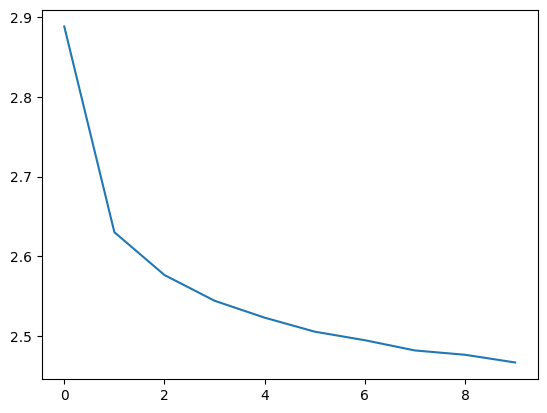

In [37]:
lstm = LSTM(len(vocab), n_dim=32)
lstm_train(lstm, dataset, epochs=10, batch_size=16, lr=0.001)

In [38]:
def gen_lstm(self, s, max_tokens=100):
    self.eval()
    h, m = self.start_mem(1)
    si = [wi[c] for c in s]
    o, h, m = self(torch.LongTensor(si).unsqueeze(0), h, m)
    lt = torch.multinomial(o[:, -1].exp(), 1)
    s += iw[lt.item()]
    for _ in range(max_tokens):
        o, h, m = self(lt, h, m)
        lt = torch.multinomial(o[:, -1].exp(), 1)
        s += iw[lt.item()]

    return s

s = 'Comp'

txt = gen_lstm(lstm, s, max_tokens=100)
print(txt)

Computer eansin:s.
^ ^ 2.-tige ary com foiuagicterstralk Ledin in
Tit secingeriases llwoonde ial loder cc


In [7]:
import torch.nn as nn
import itertools

class LSTMLayer(nn.Module):
    def __init__(self, n_dim=64):
        super(LSTMLayer, self).__init__()
        self.mem = nn.Sequential(
            nn.Linear(n_dim, n_dim),
            nn.Tanh(),
            nn.Dropout(0.2),
        )

        self.reset = nn.Sequential(
            nn.Linear(n_dim, n_dim),
            nn.Sigmoid(),
            nn.Dropout(0.2),
        )

        self.set = nn.Sequential(
            nn.Linear(n_dim, n_dim),
            nn.Sigmoid(),
            nn.Dropout(0.2),
        )

        self.no = nn.Sequential(
            nn.Linear(n_dim, n_dim),
            nn.Sigmoid(),
            nn.Dropout(0.2),
        )

    def forward(self, x, h, m):
        ji = x + h
        mem = self.mem(ji)
        rm = self.reset(ji) * m
        sm = self.set(ji) * mem
        m = rm + sm
        no = self.no(ji)
        h = no * torch.tanh(m)
        return no, h, m


class LSTM(nn.Module):
    def __init__(self, vocab_size, n_dim=64, layers=2):
        super(LSTM, self).__init__()
        self.emb = nn.Embedding(vocab_size, n_dim)

        self.lstm = nn.ModuleList([LSTMLayer(n_dim=n_dim) for _ in range(layers)])

        self.lm = nn.Sequential(
            nn.Linear(n_dim, vocab_size),
            nn.LogSoftmax(dim=-1)
        )

        self.n_dim = n_dim
        self.layers = layers

    def forward(self, x, h, m):
        emb = self.emb(x)
        emb = torch.dropout(emb, 0.1, self.training)
        o = []
        for i in range(emb.shape[1]):
            ei = emb[:, i]
            lh = []
            lm = []
            for j, layer in enumerate(self.lstm):
                ei, nh, nm = layer(ei, h[:, j], m[:, j])
                lh.append(nh)
                lm.append(nm)
            h = torch.stack(lh, dim=1)
            m = torch.stack(lm, dim=1)
            o.append(self.lm(ei))
        return torch.stack(o, dim=1), h, m

    def start_mem(self, bs):
        h = torch.zeros((bs, self.layers, self.n_dim))
        m = torch.zeros((bs, self.layers, self.n_dim))
        return h, m

# lstm = LSTM(len(vocab), n_dim=16)
# h, m = lstm.start_mem(1)
# o, h, m = lstm(dataset[0][0].unsqueeze(0), h, m)
# print(o.shape)

In [165]:
st = cleaned_text[:2000]

In [152]:
l = 8
s = 1

x = []

for i in range(0, len(st) - l, s):
    x.append([wi[c] for c in st[i:i + l]])

dataset = TensorDataset(torch.LongTensor(x))
print(len(dataset))

1992


In [18]:
def lstm_train(model, dataset, epochs=10, batch_size=16, lr=0.01):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    crit = nn.NLLLoss()

    progress = tqdm(total=len(dataset) * epochs)
    lh = []
    for _ in range(epochs):
        el = []
        for (x, ) in DataLoader(dataset, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            h, m = model.start_mem(x.shape[0])
            o, _, _ = model(x, h, m)
            loss = crit(torch.flatten(o[:, :-1], start_dim=0, end_dim=-2), torch.flatten(x[:, 1:], start_dim=0))

            loss.backward()
            optimizer.step()
            el.append(loss.item())
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))

    progress.close()
    plt.plot(lh)
    plt.show()
    return lh

  0%|          | 0/398400 [00:00<?, ?it/s]

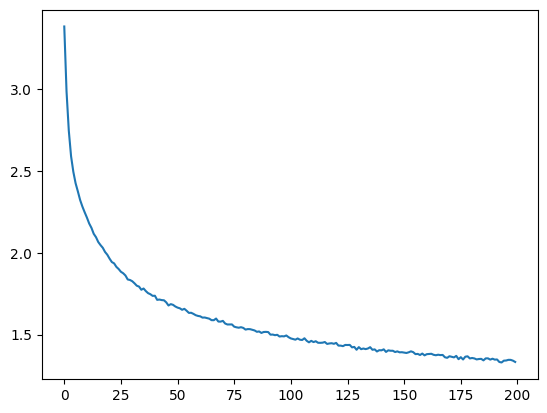

1.3323375800299266

In [158]:
lstm = LSTM(len(vocab), n_dim=128, layers=2)
lstm_train(lstm, dataset, epochs=200, batch_size=32, lr=0.001)[-1]

In [24]:
def gen_lstm(self, s, max_tokens=100):
    self.eval()
    h, m = self.start_mem(1)
    si = [wi[c] for c in s]
    o, h, m = self(torch.LongTensor(si).unsqueeze(0), h, m)
    lt = torch.multinomial(o[:, -1].exp(), 1)
    s += iw[lt.item()]
    for _ in range(max_tokens):
        o, h, m = self(lt, h, m)
        lt = torch.multinomial(o[:, -1].exp(), 1)
        s += iw[lt.item()]

    return s

s = 'Comp'

txt = gen_lstm(lstm, s, max_tokens=200)
print(txt)

KeyError: 'C'

In [8]:
vocab_tokens = tokenize(cleaned_text, 2)
wi, iw = build_vocab(vocab_tokens)

In [9]:
tokens = tokenize(cleaned_text, 2, False)

In [10]:
st = tokens[:2000]

In [14]:
from torch.utils.data import DataLoader, TensorDataset
import torch

In [15]:
l = 8
s = 1

x = []

for i in range(0, len(st) - l, s):
    x.append([wi[c] for c in st[i:i + l]])

dataset = TensorDataset(torch.LongTensor(x))
print(len(dataset))

1992


  0%|          | 0/398400 [00:00<?, ?it/s]

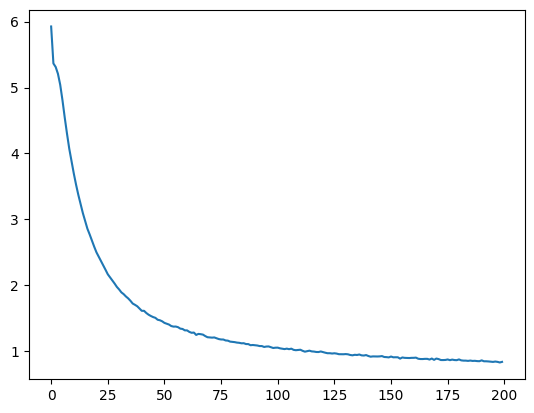

0.8384823439613222

In [171]:
lstm = LSTM(len(wi.keys()), n_dim=128, layers=2)
lstm_train(lstm, dataset, epochs=200, batch_size=32, lr=0.001)[-1]

In [174]:
s = tokenize('Comp', 2, False)
txt = gen_lstm(lstm, s, max_tokens=200)
print(''.join(txt))

Computers can perform a wide range of Timeve been increasing at a rapid tor eqre followed by the called a computer cluster.
A broad range of industrial Revolution, some mechanical devices such as smartphones. Computer (IBM ThinkCentre S50 with monitor)Video game console (Nintense, in a 1613 book called The Yong Mans Gleanings by the English Dictionary, the firsts out arithmetic or logical operations kno


In [19]:
l = 32
s = 1

x = []

for i in range(0, len(st) - l, s):
    x.append([wi[c] for c in st[i:i + l]])

dataset = TensorDataset(torch.LongTensor(x))
print(len(dataset))

1968


In [21]:
from tqdm.auto import tqdm

In [22]:
lstm = LSTM(len(wi.keys()), n_dim=128, layers=2)
lstm_train(lstm, dataset, epochs=200, batch_size=32, lr=0.001)[-1]

  0%|          | 0/393600 [00:00<?, ?it/s]

NameError: name 'plt' is not defined

In [30]:
s = tokenize('Computer', 2, False)
txt = gen_lstm(lstm, s, max_tokens=200)
print(''.join(txt))

Computers can perform generic sets of operations (computation). Modern digital electronic computers as control systems, including simple specialized analog calculations since ancient times. Early in the Industrial Revolution, some mechanical devices include input devices such as personal computers and mobile devices include input devices that perform both functions (e.g. touchscreens). Peripheral devices fr
